In [1]:
%load_ext autoreload
%autoreload 2

import json
import os
import re
import pickle
from collections import defaultdict
from itertools import product
import traceback
from pathlib import Path
from sklearn.metrics import roc_auc_score
import statistics
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from async_graph_bench import DataStore, CSVDataStore, DiskCacheStore
from matplotlib.collections import PatchCollection
from matplotlib.colors import to_rgb

from benchmark_datasets import datasets
#https://stackoverflow.com/questions/34387893/output-matplotlib-figure-to-svg-with-text-as-text-not-curves

from models import MODELS

C:\Users\PHMU3\Google Drive Dev\llm-uncertainty-bench\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys
from pathlib import Path

# add calibration_visualization to sys.path
# project_root = Path(__file__).resolve().parent.parent  # if you run as script
project_root = Path().resolve().parent
sys.path.append(str(project_root / "calibration_visualization"))

In [3]:
from plot_bucket_counts import plot_bucket_counts
from calculate_calibration_data import calculate_calibration_data, calculate_calibration_data_discrete
from plot_calibration_curve import plot_calibration_curve
from ece import calculate_ece
from normalized_entropy import calculate_normalized_entropy

## Utils

In [4]:
# Setting Font for Plots
#plt.rcParams['font.family'] = 'Palatino Linotype'
plt.rcParams['font.family'] = 'Times New Roman'
# Optional if saving SVG with text as text (not paths
plt.rcParams['svg.fonttype'] = 'none'

In [5]:
import os

dirs = ["resources", "resources/figures", "resources/tables", "resources/figures/full_plots"]

for d in dirs:
    os.makedirs(d, exist_ok=True)

In [6]:
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, np.bool_):
            return bool(obj)
        if isinstance(obj, set):
            return list(obj)
        return super().default(obj)


def numpy_decoder(dct):
    # Iterate through each key-value pair in the dictionary
    for key, value in dct.items():
        if isinstance(value, list):
            dct[key] = np.array(value)  # Convert lists to numpy arrays
        elif isinstance(value, dict):
            dct[key] = numpy_decoder(value)  # Recursively handle nested dictionaries
    return dct

# Setting Path to Data

## Prompts, Models, Datasets

In [7]:
base_path = Path(".\\data")

In [8]:
prompt_designs = [
    {"path": base_path / f"data_prompt_{i + 1}", "label": f"Prompt {i + 1}", "idx": i + 1, "basename": f"data_prompt_{i + 1}"} for i in range(4)
]
prompt_paths = [prompt["path"] for prompt in prompt_designs]

In [9]:
for model in MODELS:
    model["id"] = model["basename"]
    if "shortname" not in model:
        model["shortname"] = re.sub(r"(\-\d+|\-v\d.\d)$", "", model["id"])

model_ids = [model["id"] for model in MODELS]

# For now, only do reasoning
# models = [model for model in MODELS if model["type"] != "reasoning" and "gemma-3-27b-pt" not in model["name"]]
models = [model for model in MODELS if "gemma-3-27b-pt" not in model["name"]]

datasets_by_id = {d["id"]: d for d in datasets}

# Prompt Example Printing

In [10]:
from data_sources import get_prompt_3

dataset = datasets_by_id["MMLU"]
df = dataset["data_source"]().df

In [11]:
from IPython.display import display, HTML

item = df.iloc[10]
prompt = get_prompt_3(item["question"], item["choices"], dataset["shots"])

display(HTML(f"<pre>{prompt}</pre>"))

## Cached Data Var Initialization

In [12]:
from collections import defaultdict


def fill_defaultdict(template_dd, data_dict):
    for k, v in data_dict.items():
        if isinstance(v, dict) and isinstance(template_dd.get(k), defaultdict):
            fill_defaultdict(template_dd[k], v)
        else:
            template_dd[k] = v
    return template_dd


cached_data_file_path = "./cached_data.pkl"
cached_data = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: dict()))))

In [13]:
# Optional: Loading cached_data
# if os.path.exists(cached_data_file_path):
#     with open(cached_data_file_path, "rb") as f:  # "rb" = read binary
#         cached_data_loaded = pickle.load(f)
#         fill_defaultdict(cached_data, cached_data_loaded)
#         print(f"Metadata loaded ({cached_data_file_path})")
# else:
#     print(f"The file {cached_data_file_path} does not exist.")

# Evaluating the data

In [14]:
def get_resulting_data(data_source_df, label_prob_df, chosen_token_only=True,
                       normalize_probabilities=True):
    correct = []
    certainties = []
    accuracy = 0
    invalid_answers = 0
    once = True
    for index, row in label_prob_df.iterrows():
        mc_task = data_source_df.loc[row["id"]]
        certainties_for_row = np.array(row["confidence_per_choice"], dtype=float)
        if normalize_probabilities and np.sum(certainties_for_row) > 0.0:
            certainties_for_row /= np.sum(certainties_for_row)
        chosen_answer = np.argmax(certainties_for_row) if np.sum(certainties_for_row) > 0.0 else None
        if chosen_answer and chosen_answer == mc_task.correct_answer:
            accuracy += 1
        if (chosen_answer is None or np.isnan(chosen_answer)) and chosen_token_only:
            invalid_answers += 1
        if chosen_token_only:
            if chosen_answer is not None and not np.isnan(chosen_answer) and int(chosen_answer) < len(
                    certainties_for_row):
                correct.append(chosen_answer == mc_task.correct_answer)

                if int(chosen_answer >= len(certainties_for_row)):
                    print(f"chosen answer:{chosen_answer}, certainties for row={certainties_for_row}, task={mc_task}")

                certainties.append(certainties_for_row[int(chosen_answer)])
        else:
            for i in range(len(certainties_for_row)):
                correct.append(i == mc_task.correct_answer)
                certainties.append(certainties_for_row[i])
        once = False
    accuracy /= len(label_prob_df)
    return correct, certainties, accuracy, invalid_answers

## Calibration Plots for Multiple Dataset, Multiple Models

In [22]:
def extract_subplot_data(prompt, dataset, model, chosen_only, normalize_probabilities):
    """Extracts necessary data for a single subplot."""
    result_path = f"{prompt['path']}/{dataset['id']}/{model['id']}"
    if "df" in dataset:
        data_source_df = dataset["df"]
    else:
        data_source_df = dataset["data_source"]().df
        dataset["df"] = data_source_df
    label_prob_df = CSVDataStore(result_path, "LabelProbExtractor").to_dataframe()

    correct, label_confidences, accuracy, invalid_answers = get_resulting_data(
        data_source_df, label_prob_df,
        chosen_token_only=chosen_only, normalize_probabilities=normalize_probabilities
    )

    bin_confidences, bucket_accuracies, bucket_counts = calculate_calibration_data(correct, label_confidences, 15)
    ece = calculate_ece(bin_confidences, bucket_accuracies, bucket_counts)
    try:
        auroc = roc_auc_score(correct, label_confidences)
    except:
        print("prompt=", prompt['basename'])
        print("dataset=", dataset['id'])
        print("model=", model['name'])
        auroc = "undefined"
    sum_series = label_prob_df["confidence_per_choice"].apply(sum).apply(lambda e: max(0.0, min(1.0, e)))
    try:
        result = {
            "is_normalized": normalize_probabilities,
            "bin_confidences": bin_confidences,
            "bucket_accuracies": bucket_accuracies,
            "bucket_counts": bucket_counts,
            "ece": ece,
            "auroc": auroc,
            "accuracy": accuracy,
            "label_prob_sum_mean": sum_series.mean(),
            "label_prob_sum_median": sum_series.quantile(0.5),
            "label_prob_sum_std": sum_series.std(),
            "label_prob_sum_iqr": sum_series.quantile(0.75) - sum_series.quantile(0.25),

            "normalized_entropy": calculate_normalized_entropy(bucket_counts),
            "total_items": len(label_prob_df),
            "sum_series": sum_series,
            "invalid_answers": invalid_answers
        }
        if len(label_confidences):
            result["label_prob_median"] = np.median(label_confidences)
            result["label_prob_iqr"] = np.percentile(label_confidences, 75) - np.percentile(label_confidences, 25)
            result["average_certainty"] = np.mean(label_confidences)
        else:
            result["label_prob_median"] = "undefined"
            result["label_prob_iqr"] = "undefined"
            result["average_certainty"] = "undefined"
        return result
    except IndexError as e:
        print(f"Encoutered Index Error running for {dataset['id']}/{model['id']}")
        print("label_confidences=", label_confidences)
        traceback.print_exc()


def plot_empty(ax, message="No Data Available"):
    """
    Displays a placeholder plot with a light grey background and a centered message.

    Args:
        ax (matplotlib.axes.Axes): The axes to plot onto.
        message (str): The message to display in the center.
    """
    ax.set_facecolor("#f0f0f0")  # Light grey background
    ax.text(0.5, 0.5, message,
            horizontalalignment='center',
            verticalalignment='center',
            fontsize=14,
            color="#555555",  # Darker grey text
            transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_frame_on(False)


def plot_subplot(ax, data, model_type: str, show_x_label=True, show_y_label=True, ece_in_plot=False):
    """Plots calibration data on a given axis and optionally adds a table."""
    plot_calibration_curve(
        data["bin_confidences"], data["bucket_accuracies"], data["bucket_counts"],
        ax=ax, colormap="Blues" if model_type == "instruct" else "Greens" if model_type == "reasoning" else "Oranges",
        fontsize=14, tick_fontsize=10,
        xlabel="Confidence Bins" if show_x_label else None, ylabel="Accuracy in Bin" if show_y_label else None,
        ece=data["ece"] if ece_in_plot else None
    )


def safe_format(val, format="4f") -> str:
    try:
        return f"{val:.{format}}"
    except (TypeError, ValueError):
        return str(val)


def plot_table(ax, data):
    table_data = [
        ["ECE", safe_format(data['ece'])],
        ["AUROC", safe_format(data['auroc'])],
        ["Norm. Entropy of Bucket Counts", safe_format(data['normalized_entropy'])],
        ["Invalid Answer Count", f"{data['invalid_answers']}/{data['total_items']}"],
        ["Accuracy", safe_format(data['accuracy'])],
        ["Median of Label Probabilities", safe_format(data['label_prob_median'])],
        ["IQR of Label Probabilities", safe_format(data['label_prob_iqr'])],
        ["Median of Sum of Label Probabilities", safe_format(data['label_prob_sum_median'])],
        ["IQR of Sum of Label Probabilities", safe_format(data['label_prob_sum_iqr'])],
    ]

    table = ax.table(cellText=table_data, loc='center', cellLoc='center')
    # table.set_position([0.5, 0.3])  # (x, y) position in axes coordinates (0 to 1)
    table.auto_set_font_size(False)
    table.set_fontsize(10)

    # Iterate over each cell and set alignment based on the column.
    for (row, col), cell in table.get_celld().items():
        if col == 0:  # First column: right aligned.
            cell.PAD = 0.02
            cell.get_text().set_ha('right')
            cell.set_width(0.65)  # Adjust as needed
        elif col == 1:  # Second column: left aligned.
            cell.PAD = 0.04
            cell.get_text().set_ha('left')
            cell.set_width(0.35)  # Adjust as needed

    ax.axis('off')


def generate_grid_plot(cell_data, row_titles, col_titles, sharex=False, sharey=False,
                       with_table=False, show_axis_labels=False, skip_annotation=False, row_col_titles_font_size=40,
                       title_font_size=52, plot_title=None, ece_in_plot=False):
    """
    Generates a grid of subplots.

    When with_table is True, the grid will have double the rows:
      - The even-numbered rows (0,2,…) display calibration curves.
      - The odd-numbered rows (1,3,…) display the corresponding tables.

    Args:
        cell_data (list[list[tuple]]): A 2D list (rows x columns) where each cell is a tuple (data, model).
        row_titles (list[str]): Titles for each original row (displayed on the left of the calibration rows).
        col_titles (list[str]): Titles for each column (displayed on the top).
        plot_title (str): Overall title for the figure.
        sharex (bool): Whether to share the x-axis among subplots.
        sharey (bool): Whether to share the y-axis among subplots.
        figsize (tuple): Figure size. If None, computed as (n_cols*6, n_rows*6) or adjusted if with_table.
        with_table (bool): If True, each original row is split into two rows: calibration curve and table.

    Returns:
        tuple: (fig, axes) matplotlib objects.
    """
    original_n_rows = len(cell_data)
    n_cols = len(cell_data[0]) if original_n_rows else 0
    figsize = (n_cols * 6, original_n_rows * (6 + (2.5 if with_table else 0)))

    n_rows = original_n_rows * 2 if with_table else original_n_rows
    if with_table:
        # Compute figure height as calibration row height (6) plus table row height (1.8) per original row.
        # Build height ratios: for each original row, calibration row gets ratio 1 and table row gets 0.15.
        height_ratios = []
        for _ in range(original_n_rows):
            height_ratios.extend([1, 0.15])
        fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharex=sharex, sharey=sharey,
                                 gridspec_kw={'height_ratios': height_ratios})
    else:
        fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharex=sharex, sharey=sharey)

    # Ensure axes is a 2D array.
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = np.array([axes])
    elif n_cols == 1:
        axes = axes.reshape(n_rows, 1)

    # Loop over grid cells.
    for i in range(original_n_rows):
        for j in range(n_cols):
            try:
                subplot_ax = axes[2 * i if with_table else i, j]
                data, model_type = cell_data[i][j]
                plot_subplot(subplot_ax, data, model_type, ece_in_plot=ece_in_plot)
            except:
                print("subplot unplottable")
                plot_empty(subplot_ax)
            subplot_ax.set_aspect(1)  # Enforce square aspect ratio.
            if with_table:
                table_ax = axes[2 * i + 1, j]
                plot_table(table_ax, data)
            # Keep reserved space by making redundant axis labels transparent.
            if not with_table and not show_axis_labels:
                if i < n_rows - 1:
                    subplot_ax.xaxis.label.set_color("none")
                if j > 0:
                    subplot_ax.yaxis.label.set_color("none")
            # Set column header on the top row (if with_table, top row of each pair i.e. when i==0).
            if i == 0 and not skip_annotation:
                subplot_ax.set_title(col_titles[j], fontsize=row_col_titles_font_size, fontweight="bold",
                                     y=1.05)  # col title padding
        # Set row annotation on the leftmost subplot.
        if not skip_annotation:
            front_subplot_ax = axes[2 * i if with_table else i, 0]
            front_subplot_ax.annotate(
                row_titles[i],
                xy=(-0.15, 0.5), xycoords='axes fraction',  # row title padding
                fontsize=row_col_titles_font_size, fontweight="bold", ha="center", va="center", rotation=90
            )

    # Add text with absolute offset
    if plot_title and not skip_annotation:
        fig.text(0.5, 1.01, plot_title, ha='center', va='bottom', fontsize=title_font_size, fontweight='bold')
    plt.tight_layout()
    return plt

In [16]:
sum_of_token_probs = defaultdict(list)

In [17]:
def create_full_plot(prompt, datasets, models, chosen_only, normalize_probabilities, with_table, skip_annotation=False,
                     with_title=True, kwargs=dict(), ece_in_plot=False):
    """
    Creates and saves the full plot with subplots for all datasets and models.

    When with_table is True, each dataset row is split into two: the calibration curve (top)
    and its corresponding table (bottom). Also updates cached_data and sum of token probabilities.
    """
    # global cached_data1
    global cached_data, sum_of_token_probs
    cell_data = []
    for dataset in datasets:
        row = []
        for model in models:

            key = "chosen_labels" if chosen_only else "all_labels"
            if key in cached_data['normalized' if normalize_probabilities else 'non-normalized'][prompt["basename"]][
                dataset["id"]][model["id"]]:
                data = cached_data['normalized' if normalize_probabilities else 'non-normalized'][prompt["basename"]][
                    dataset["id"]][
                    model["id"]][key]
            else:
                data = extract_subplot_data(prompt, dataset, model, chosen_only, normalize_probabilities)
                cached_data['normalized' if normalize_probabilities else 'non-normalized'][prompt["basename"]][dataset["id"]][
                    model["id"]][key] = data
            sum_of_token_probs[model["id"]].append(
                data["label_prob_sum_mean"]
            )
            row.append((data, model["type"]))
        cell_data.append(row)

    row_titles = [ds["id"] for ds in datasets]
    col_titles = [model["shortname"] for model in models]
    plot_title = (
        f"Calibration of "
        f"{'Normalized' if normalize_probabilities else 'Non-Normalized'} "
        f"Label Probabilities for {prompt['label']} "
        f"{'(Most Probable Label per Question Only)' if chosen_only else '(All Labels)'}"
    )

    plot = generate_grid_plot(cell_data, row_titles, col_titles,
                              with_table=with_table, skip_annotation=skip_annotation,
                              plot_title=plot_title if with_title else None, ece_in_plot=ece_in_plot, **kwargs)
    return plot


def generate_plots_for_configs(prompt_designs, datasets, models):
    """Loops over multiple configurations and generates corresponding plots."""
    for prompt in prompt_designs:
        variations = list(product([True, False], repeat=3))
        for chosen_only, with_table, normalize_probabilities in variations:
            try:
                print(
                    "Generating " + f"{prompt['basename']}/cal_plot_prompt{prompt['idx']}_table{int(with_table)}_chosenonly{int(chosen_only)}_norm{int(normalize_probabilities)}.svg")
                plot = create_full_plot(prompt, datasets, models, chosen_only, normalize_probabilities, with_table,
                                        with_title=True,
                                        kwargs={"sharex": False, "sharey": False, "row_col_titles_font_size": 26})
                # plot.show()
                plot.savefig(
                    f"resources/figures/full_plots/cal_plot_prompt{prompt['idx']}_table{int(with_table)}_chosenonly{int(chosen_only)}_norm{int(normalize_probabilities)}.svg",
                    bbox_inches="tight")
                plot.close()
            except Exception as e:
                print(e)
                print("Failed to create plot")

In [40]:
# Run full plot generation
generate_plots_for_configs(prompt_designs, datasets, models)

Generating data_prompt_1/cal_plot_prompt1_table1_chosenonly1_norm1.svg
Generating data_prompt_1/cal_plot_prompt1_table1_chosenonly1_norm0.svg
Generating data_prompt_1/cal_plot_prompt1_table0_chosenonly1_norm1.svg
Generating data_prompt_1/cal_plot_prompt1_table0_chosenonly1_norm0.svg
Generating data_prompt_1/cal_plot_prompt1_table1_chosenonly0_norm1.svg
Generating data_prompt_1/cal_plot_prompt1_table1_chosenonly0_norm0.svg
Generating data_prompt_1/cal_plot_prompt1_table0_chosenonly0_norm1.svg
Generating data_prompt_1/cal_plot_prompt1_table0_chosenonly0_norm0.svg
Generating data_prompt_2/cal_plot_prompt2_table1_chosenonly1_norm1.svg
Generating data_prompt_2/cal_plot_prompt2_table1_chosenonly1_norm0.svg
Generating data_prompt_2/cal_plot_prompt2_table0_chosenonly1_norm1.svg
Generating data_prompt_2/cal_plot_prompt2_table0_chosenonly1_norm0.svg
Generating data_prompt_2/cal_plot_prompt2_table1_chosenonly0_norm1.svg
Generating data_prompt_2/cal_plot_prompt2_table1_chosenonly0_norm0.svg
Genera

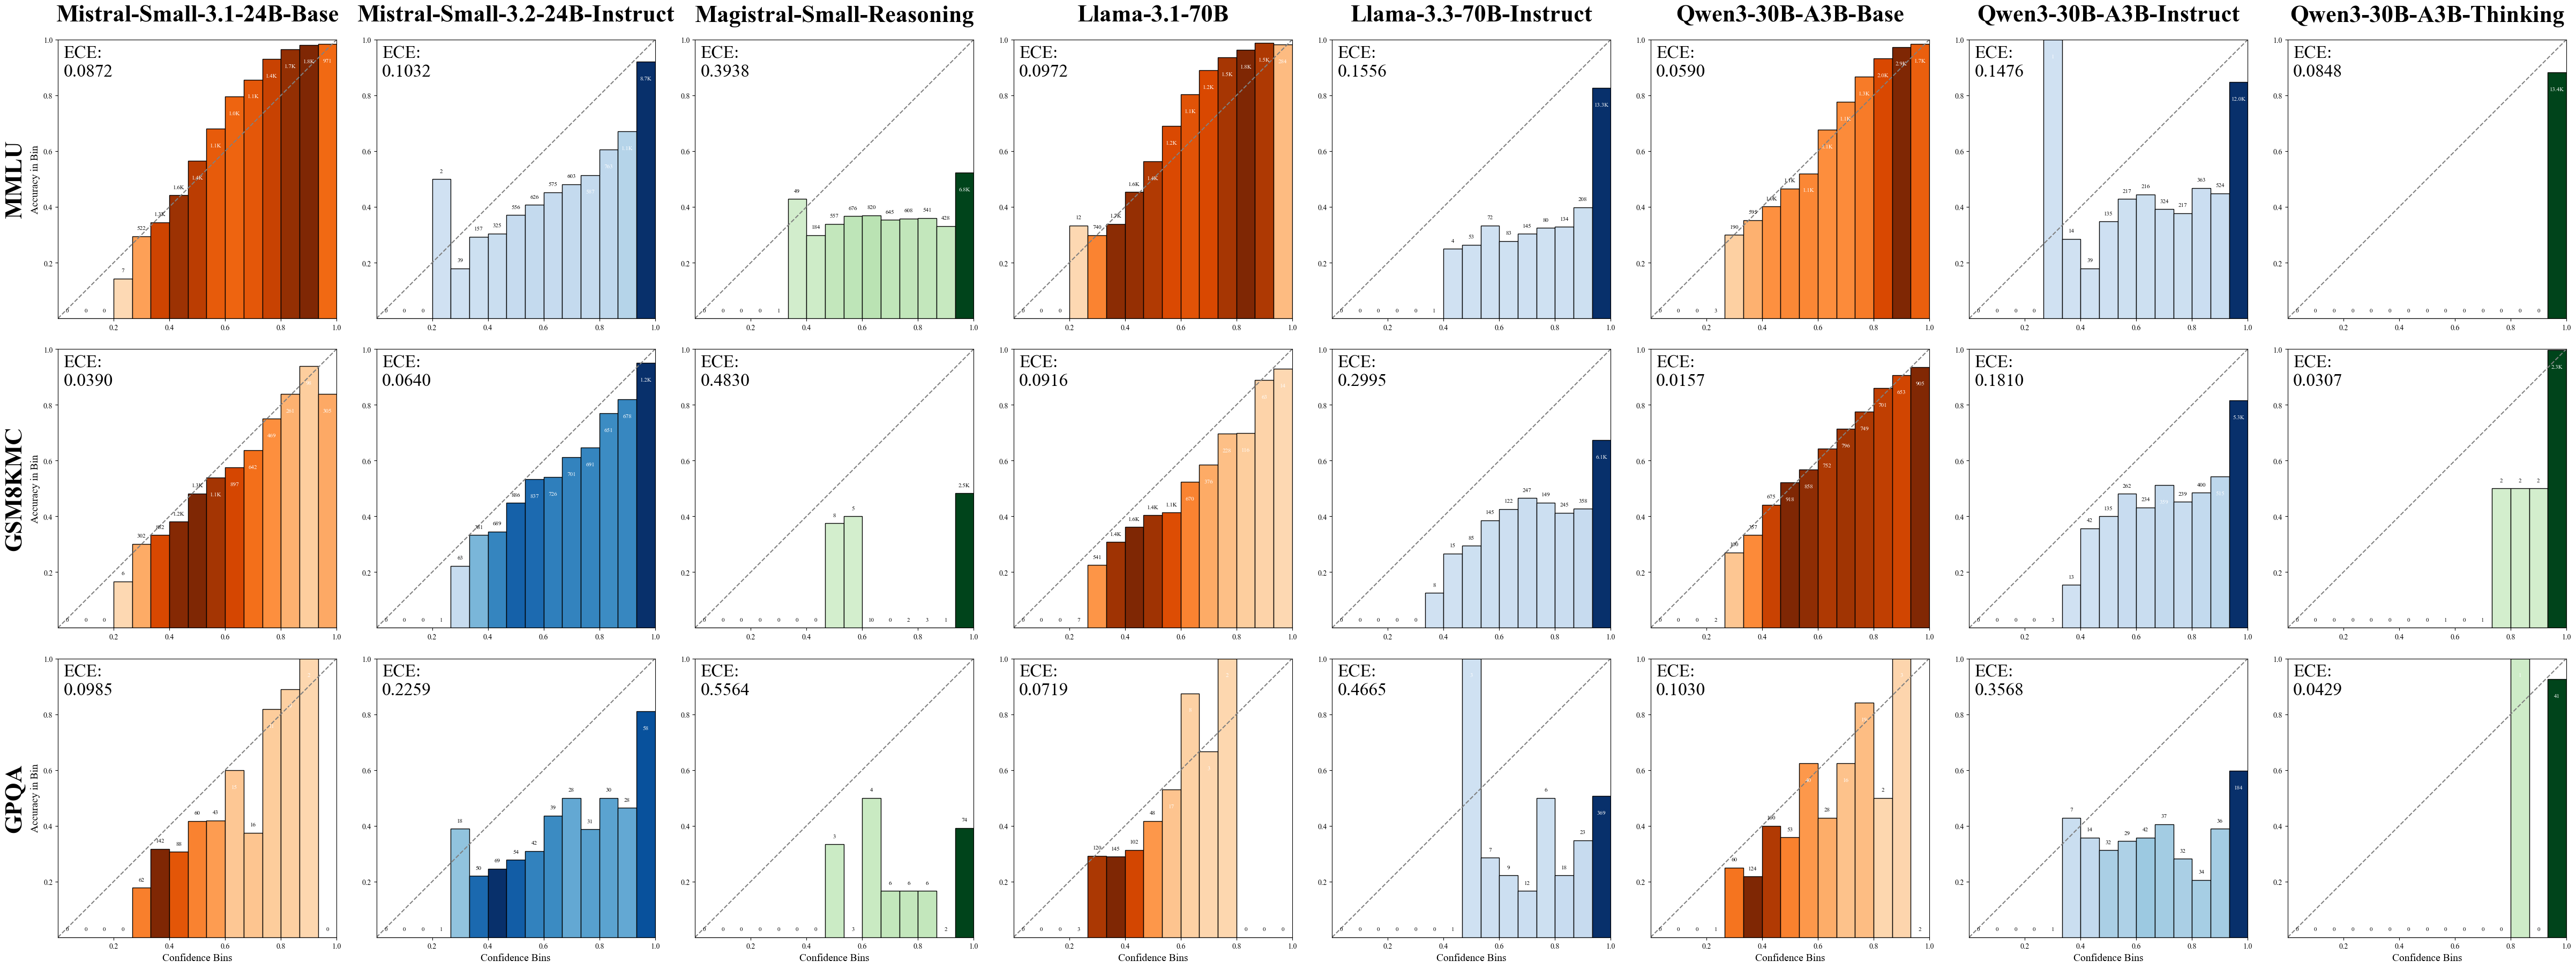

In [24]:
plot = create_full_plot(
    prompt_designs[0],
    [d for d in datasets if d["id"] in ["MMLU", "GSM8KMC", "GPQA"]],
    [m for m in models if any(name in m['basename'] for name in ["Mistral-Small-3", "Magistral-Small-2507-Reasoning-Enabled", "Llama-3", "Qwen3-30B-A3B"])],
    chosen_only=True, normalize_probabilities=True,
    with_table=False, with_title=False,
    ece_in_plot=True,
    kwargs={
        "row_col_titles_font_size": 32,
    #     "title_font_size": 12,
    }
)

plot.savefig(f"resources/figures/prompt_1_header_plot.svg", bbox_inches="tight")
plot.show()

# Saving Cached Data

In [21]:
import pickle
from collections import defaultdict


def strip_defaultdict(d):
    if isinstance(d, defaultdict):
        d = {k: strip_defaultdict(v) for k, v in d.items()}
    elif isinstance(d, dict):
        d = {k: strip_defaultdict(v) for k, v in d.items()}
    return d


cached_data_picklable = strip_defaultdict(cached_data)

with open("./cached_data.pkl", "wb") as f:  # "wb" = write binary
    pickle.dump(dict(cached_data_picklable), f)

# Effect of Normalization

In [22]:
cached_normalization_data = None

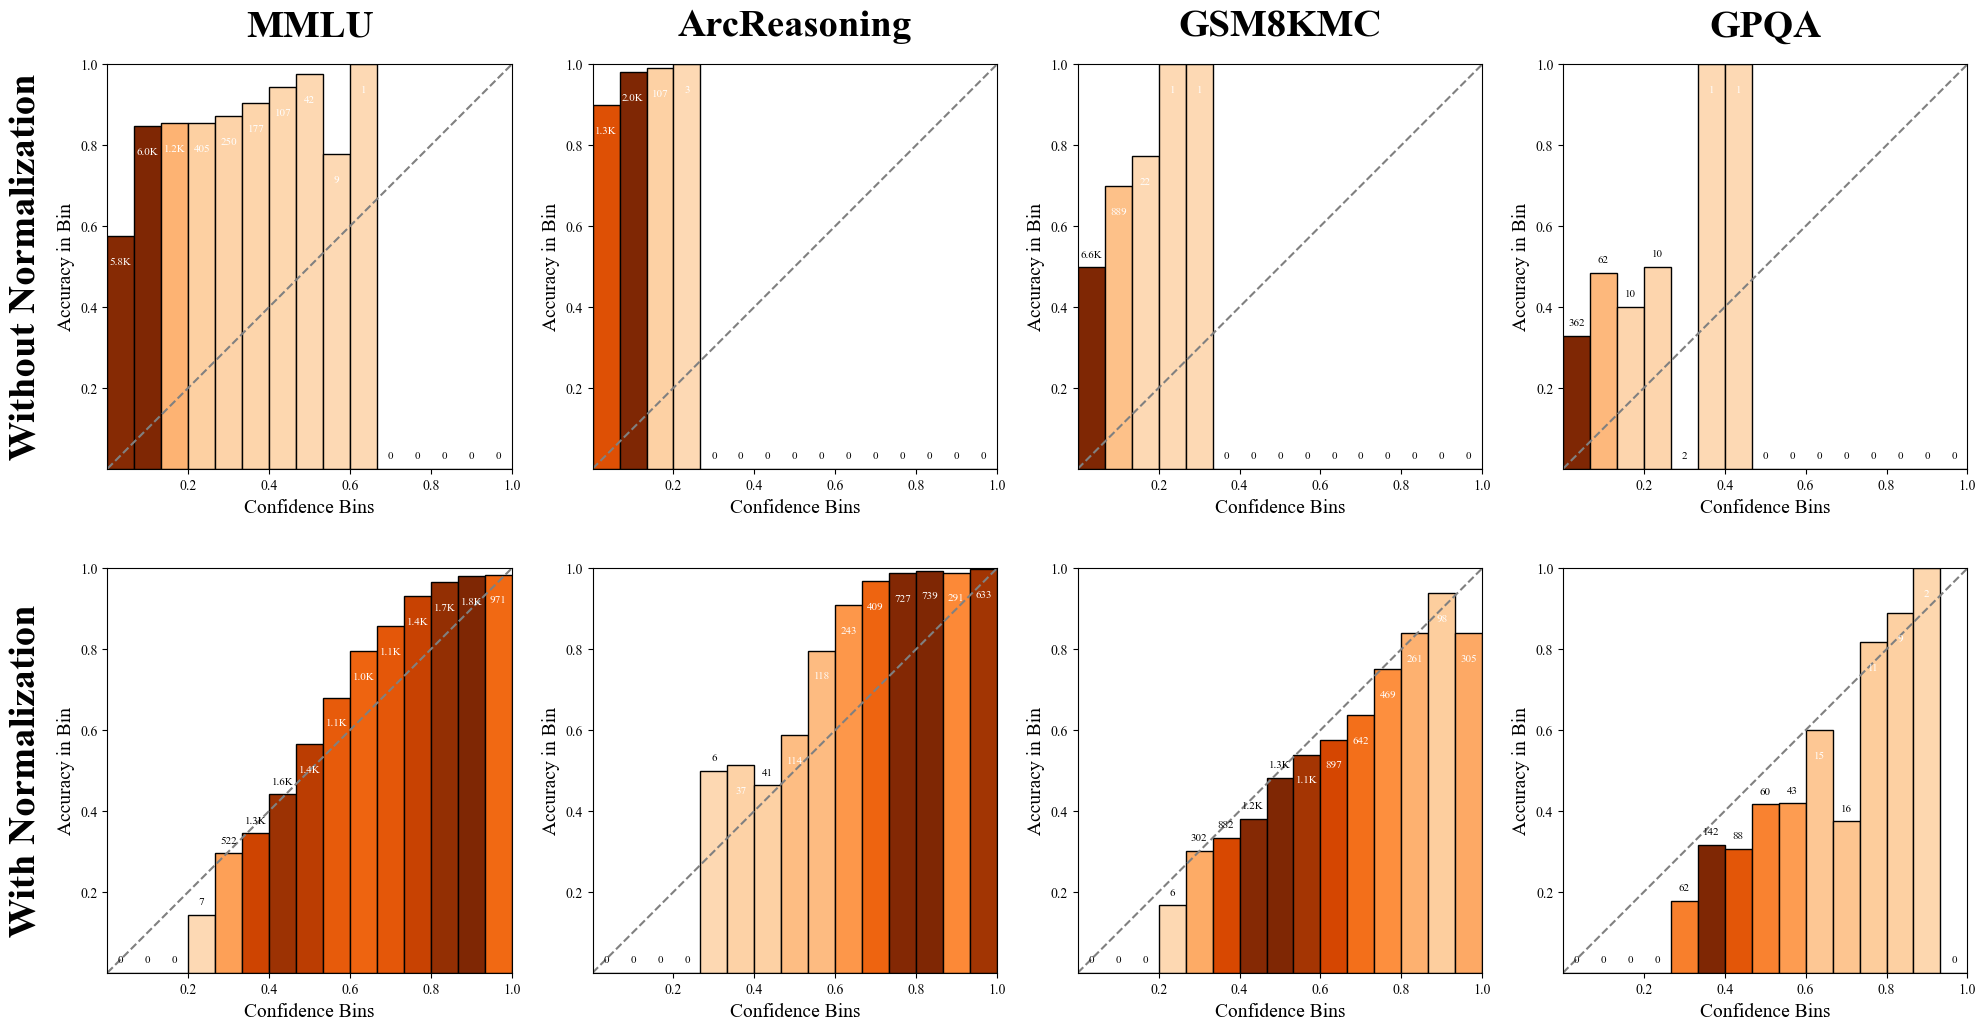

In [23]:
def generate_normalization_effect_plot(model, datasets, prompt):
    # global cached_normalization_data
    row_labels = ["Without Normalization", "With Normalization"]
    col_titles = [ds["id"] for ds in datasets]

    # Build cell data: each cell is computed for a given normalization setting.
    cell_data = []
    # if not cached_normalization_data:
    for normalize in [False, True]:
        row = []
        for dataset in datasets:
            data = extract_subplot_data(prompt, dataset, model, chosen_only=True, normalize_probabilities=normalize)
            row.append([data, model["type"]])
        cell_data.append(row)
    # cached_normalization_data = cell_data

    # plot_title = f"Normalization Effect for {model['id']}"
    plot = generate_grid_plot(cell_data, row_labels, col_titles, sharex=False, sharey=False,
                              with_table=False, show_axis_labels=True, plot_title=None, row_col_titles_font_size=28)

    plot.savefig(
        f"resources/figures/normalization_effect_prompt{prompt['idx']}_{model['id']}.svg", bbox_inches="tight")
    plot.show()
    # plot.close()


generate_normalization_effect_plot(
    next(m for m in models if "Mistral-Small-3.1-24B-Base-2503" in m["id"]),
    datasets,
    prompt_designs[0]
)

# RQ 1 Additional Plots

## Label Prob Sum per Prompt

In [24]:
from matplotlib.legend_handler import HandlerBase


# ---- Custom Legend ----
class MulticolorPatch(object):
    def __init__(self, colors):
        self.colors = colors


class MulticolorPatchHandler(HandlerBase):
    def legend_artist(self, legend, orig_handle, fontsize, handlebox):
        width, height = handlebox.width, handlebox.height
        patches = [
            mpatches.Rectangle(
                [width / 2 * i - handlebox.xdescent, -handlebox.ydescent],
                width / 2, height,
                facecolor=c, edgecolor='black'
            ) for i, c in enumerate(orig_handle.colors)
        ]
        patch_collection = PatchCollection(patches, match_original=True)
        handlebox.add_artist(patch_collection)
        return patch_collection

In [25]:
def lighten_color(color, amount=0.5):
    c = np.array(to_rgb(color))
    return np.clip(c + (1 - c) * amount, 0, 1)


base_instruct = "tab:blue"
base_base = "tab:orange"
base_reasoning = "tab:green"
shades = [0.0, 0.2, 0.4, 0.6]

prompt_colors = {
    prompt['basename']: {
        "instruct": lighten_color(base_instruct, amount=shades[i]),
        "base": lighten_color(base_base, amount=shades[i]),
        "reasoning": lighten_color(base_reasoning, amount=shades[i])
    } for i, prompt in enumerate(prompt_designs)
}

model_ids = [model["id"] for model in models]
dataset_id = datasets[0]["id"]

plot_data = {model: {} for model in model_ids}
for i, prompt in enumerate(prompt_designs):
    prompt_id = prompt['basename']
    for model in model_ids:
        try:
            metrics = cached_data["normalized"][prompt_id][dataset_id][model]["chosen_labels"]
            plot_data[model][prompt_id] = (metrics["label_prob_sum_mean"], metrics["label_prob_sum_std"])
        except KeyError:
            plot_data[model][prompt_id] = (0, 0)

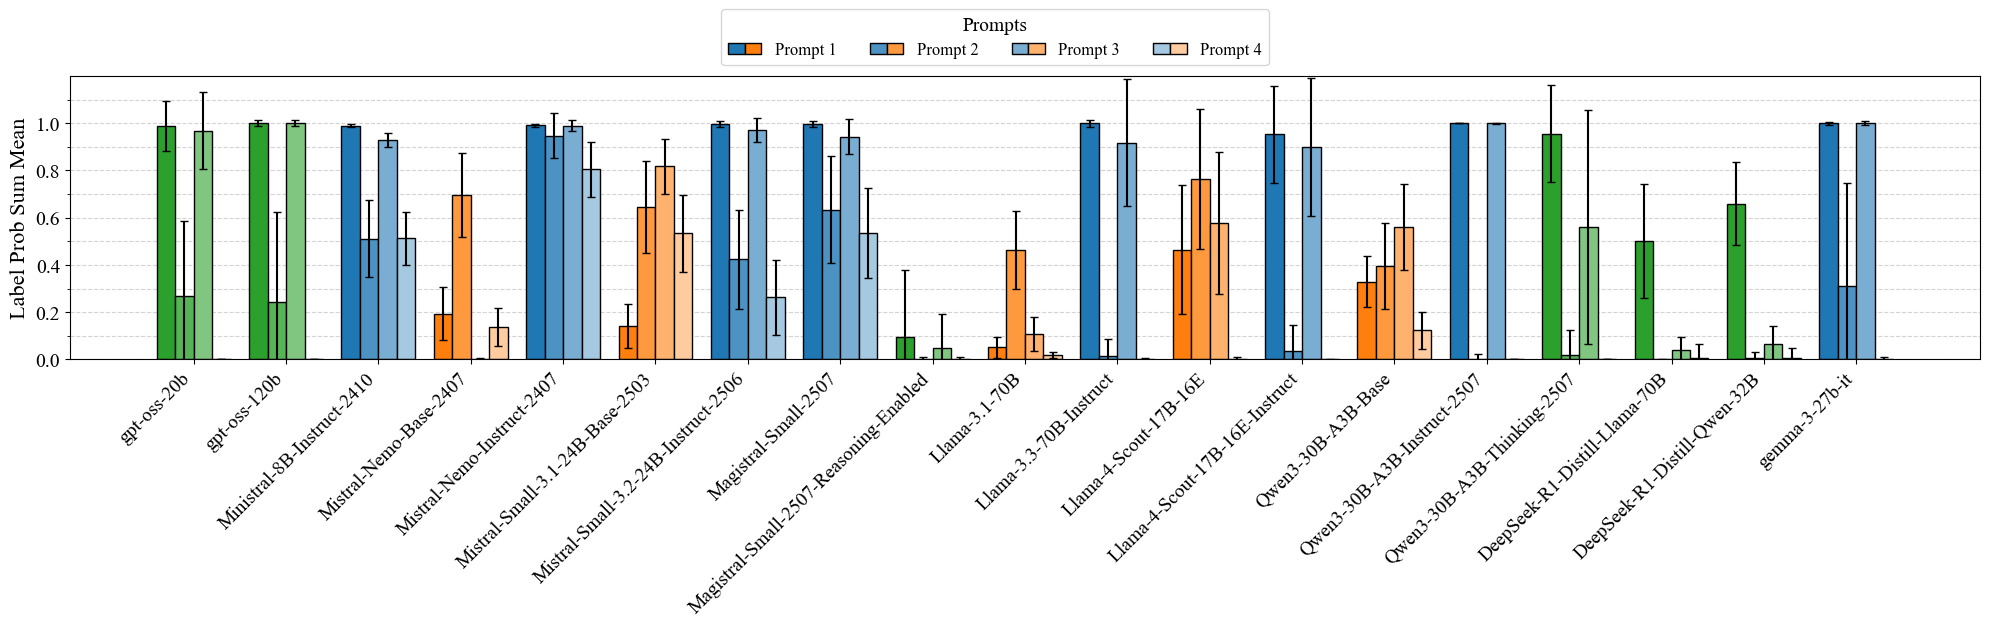

In [26]:
n_models = len(model_ids)
n_prompts = len(prompt_designs)
width = 0.2
x = np.arange(n_models)
# plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(figsize=(20, 6))

# for j, prompt in enumerate(prompt_ids):
for j, prompt in enumerate(prompt_designs):
    offset = (j - (n_prompts - 1) / 2) * width
    for i, model in enumerate(models):
        mean, std = plot_data[model['id']][prompt['basename']]
        xpos = x[i] + offset
        color = prompt_colors[prompt['basename']][model["type"]]
        ax.bar(xpos, mean, width, yerr=std, capsize=3, color=color, edgecolor='black', label=prompt['basename'] if i == 0 else "")

# Axis formatting
ax.set_xticks(x)
ax.set_xticklabels(model_ids, rotation=45, ha="right", fontsize=14)
ax.set_ylabel("Label Prob Sum Mean", fontsize=16)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=14)
# ax.set_title("Influence of Prompt on Label Prob Sum Mean")
ax.set_ylim(0, 1.2)
ax.set_axisbelow(True)
ax.yaxis.grid(True)
ax.set_yticks(np.arange(0.0, 1.2, 0.1), minor=True)
ax.grid(axis='y', color='lightgrey', linestyle='--')
ax.grid(axis='y', which="minor", color='lightgrey', linestyle='--')

legend_entries = []
legend_labels = []
for j, prompt in enumerate(prompt_designs):
    instruct_color = prompt_colors[prompt['basename']]["instruct"]
    base_color = prompt_colors[prompt['basename']]["base"]
    patch = MulticolorPatch([instruct_color, base_color])
    legend_entries.append(patch)
    legend_labels.append(prompt['label'])

fig.legend(legend_entries, legend_labels,
           handler_map={MulticolorPatch: MulticolorPatchHandler()},
           loc='upper center', ncol=n_prompts, title='Prompts',
           bbox_to_anchor=(0.5, 1.05), fontsize=12, title_fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.draw()
plt.savefig("resources/figures/label_prob_calibration.svg", bbox_inches="tight")
plt.savefig("resources/figures/label_prob_calibration.png", bbox_inches="tight")
plt.show()

# Table on the influence of prompt design on label prob sum

In [28]:
import numpy as np

# ---- Data Aggregation ----

# Initialize accumulators for base and instruction-tuned models
prompt_ids = [prompt['basename'] for prompt in prompt_designs]

means = {
    key: {prompt: [] for prompt in prompt_ids} for key in ["base", "instruct", "reasoning"]
}
stds = {
    key: {prompt: [] for prompt in prompt_ids} for key in ["base", "instruct", "reasoning"]
}

for prompt in prompt_ids:
    for model in models:
        mean, std = plot_data[model["id"]][prompt]
        means[model["type"]][prompt].append(mean)
        stds[model["type"]][prompt].append(std)

# Compute aggregated values
table_data = {"Base Models": {}, "Instruction Tuned Models": {}, "Reasoning Models": {}, "Average": {}}

model_types = ["base", "instruct", "reasoning"]

for prompt in prompt_ids:
    # Compute means
    aggregate_means = {
        type: np.mean(means[type][prompt]) if means[type][prompt] else 0 for type in model_types
    }
    aggregate_means['avg'] = statistics.fmean(aggregate_means.values())

    # Compute std deviations correctly
    # base_std = np.sqrt(np.sum(np.square(stds["base"][prompt]))) if stds["base"][prompt] else 0
    # instruct_std = np.sqrt(np.sum(np.square(stds["instruct"][prompt]))) if stds["instruct"][prompt] else 0
    # avg_std = np.sqrt((base_std ** 2 + instruct_std ** 2) / 2)  # Combine stds for average row

    # Store formatted results
    table_data["Base Models"][prompt] = f"{aggregate_means['base']:.4f}"  #± {base_std:.4f}
    table_data["Instruction Tuned Models"][prompt] = f"{aggregate_means['instruct']:.4f}"  # ± {instruct_std:.4f}
    table_data["Reasoning Models"][prompt] = f"{aggregate_means['reasoning']:.4f}"  # ± {instruct_std:.4f}
    table_data["Average"][prompt] = f"{aggregate_means['avg']:.4f}"  # ± {avg_std:.4f}

# ---- Generate LaTeX Table ----

latex_table = """
\\begin{table}[h]
    \\centering
    \\begin{tabular}{lcccc}
        \\toprule
        & Prompt 1 & Prompt 2 & Prompt 3 & Prompt 4 \\\\
        \\midrule
"""

for row_name, values in table_data.items():
    row_values = " & ".join(values[prompt] for prompt in prompt_ids)
    latex_table += f"        {row_name} & {row_values} \\\\\n"

latex_table += """        \\bottomrule
    \\end{tabular}
    \\caption{Mean over Sum of Label Probabilities per Question for Base and Instruction Tuned Models}
    \\label{tab:labelprobsum}
\\end{table}
"""

with open("resources/tables/prompt_design_label_prob_sum.tex", "w", encoding="utf-8") as f:
    f.write(latex_table)
print(latex_table)


\begin{table}[h]
    \centering
    \begin{tabular}{lcccc}
        \toprule
        & Prompt 1 & Prompt 2 & Prompt 3 & Prompt 4 \\
        \midrule
        Base Models & 0.2368 & 0.5928 & 0.4135 & 0.1632 \\
        Instruction Tuned Models & 0.9912 & 0.3597 & 0.9561 & 0.2646 \\
        Reasoning Models & 0.7002 & 0.0895 & 0.4475 & 0.0022 \\
        Average & 0.6427 & 0.3474 & 0.6057 & 0.1434 \\
        \bottomrule
    \end{tabular}
    \caption{Mean over Sum of Label Probabilities per Question for Base and Instruction Tuned Models}
    \label{tab:labelprobsum}
\end{table}



In [29]:
for dataset in datasets:
    accuracies = []
    # for prompt in prompt_paths:
    for model in models:
        accuracies.append(
            cached_data["normalized"]["data_prompt_3"][dataset['id']][model['id']]["chosen_labels"]["accuracy"])
    print("Accuracy for", dataset['id'], ":", np.mean(accuracies))

Accuracy for MMLU : 0.5229704015772232
Accuracy for ArcReasoning : 0.7093508040500297
Accuracy for GSM8KMC : 0.4671158345784117
Accuracy for GPQA : 0.2712640977443609


Table showing impact of prompt design on ECE

In [30]:
import numpy as np

property = "ece"

# ---- Data Extraction ----
table_data = {}
dataset_stats = {}

for dataset in datasets:
    dataset_id = dataset["id"]
    table_data[dataset_id] = {}

    deviations = []
    means = []

    for model in model_ids:
        prop_list = []
        table_data[dataset_id][model] = {}

        for prompt in prompt_paths:
            try:
                value = cached_data["normalized"][prompt][dataset_id][model][
                    "all_labels" if property == "calibration_gap" else "chosen_labels"
                ][property]
            except KeyError:
                value = 0  # Default to 0 if missing
            table_data[dataset_id][model][prompt] = value
            prop_list.append(value)

        # Compute Mean & Deviation
        mean_value = np.mean(prop_list)
        deviation = np.std(prop_list)

        table_data[dataset_id][model]["Mean"] = mean_value
        table_data[dataset_id][model]["Deviation"] = deviation
        means.append(mean_value)
        deviations.append(deviation)

    # Compute dataset-level stats
    dataset_stats[dataset_id] = {
        "mean_deviation": np.mean(deviations),
        "std_deviation": np.std(deviations),
        "mean_mean": np.mean(means)
    }

# ---- Generate LaTeX Table ----

latex_table = f"""
\\begin{{table}}[h]
    \\centering
    \\makebox[\\textwidth][c]{{%
    \\begin{{tabular}}{{l|lcccc|cc}}
        \\toprule
        Dataset & Model & Prompt 1 & Prompt 2 & Prompt 3 & Prompt 4 & Mean & max-min \\\\
        \\midrule
"""

for dataset_id, model_ids in table_data.items():
    first_row = True

    for model, prop_values in model_ids.items():
        row_values = " & ".join(f"{prop_values[prompt]:.4f}" for prompt in prompt_paths)
        mean_value = f"{prop_values['Mean']:.4f}"
        deviation = f"{prop_values['Deviation']:.4f}"
        prop_values_prompts = [prop_values[prompt] for prompt in prompt_paths]
        max_minus_min = f"{max(prop_values_prompts) - min(prop_values_prompts):.4f}"

        if first_row:
            latex_table += f"        \\multirow{{{len(model_ids)}}}{{*}}{{{dataset_id}}} & {model} & {row_values} & {mean_value} & {max_minus_min} \\\\\n"
            first_row = False
        else:
            latex_table += f"        & {model} & {row_values} & {mean_value} & {max_minus_min} \\\\\n"

    latex_table += "        \\midrule\n"

# ---- Compute Overall Caption Statistics ----

caption_stats = []
for dataset_id, stats in dataset_stats.items():
    mean_dev = f"{stats['mean_deviation']:.4f}"
    std_dev = f"{stats['std_deviation']:.4f}"
    mean_mean = f"{stats['mean_mean']:.4f}"
    caption_stats.append(
        f"{dataset_id}: $\\mu_{{dev}}$={mean_dev}, $\\sigma_{{dev}}$={std_dev}, $\\mu_{{mean}}$={mean_mean}")

caption_text = " ".join(caption_stats)

# ---- Finalize Table ----

property_name = "ECE" if property == "ece" else "Calibration Gap"

latex_table += f"""        \\bottomrule
    \\end{{tabular}}
    }}
    \\caption{{{property_name} Across Prompts {"(using Probability for all Labels)" if property == "calibration_gap" else "(using Probability of chosen Labels only)"} with Mean and Deviation for each Dataset. Dataset-level statistics: {caption_text}.}}
    \\label{{tab:{property}}}
\\end{{table}}
"""

print(latex_table)
with open(f"prompt_design_{property}.tex", "w", encoding="utf-8") as f:
    f.write(latex_table)


\begin{table}[h]
    \centering
    \makebox[\textwidth][c]{%
    \begin{tabular}{l|lcccc|cc}
        \toprule
        Dataset & Model & Prompt 1 & Prompt 2 & Prompt 3 & Prompt 4 & Mean & max-min \\
        \midrule
        \multirow{19}{*}{MMLU} & gpt-oss-20b & 0.0000 & 0.0000 & 0.0000 & 0.0000 & 0.0000 & 0.0000 \\
        & gpt-oss-120b & 0.0000 & 0.0000 & 0.0000 & 0.0000 & 0.0000 & 0.0000 \\
        & Ministral-8B-Instruct-2410 & 0.0000 & 0.0000 & 0.0000 & 0.0000 & 0.0000 & 0.0000 \\
        & Mistral-Nemo-Base-2407 & 0.0000 & 0.0000 & 0.0000 & 0.0000 & 0.0000 & 0.0000 \\
        & Mistral-Nemo-Instruct-2407 & 0.0000 & 0.0000 & 0.0000 & 0.0000 & 0.0000 & 0.0000 \\
        & Mistral-Small-3.1-24B-Base-2503 & 0.0000 & 0.0000 & 0.0000 & 0.0000 & 0.0000 & 0.0000 \\
        & Mistral-Small-3.2-24B-Instruct-2506 & 0.0000 & 0.0000 & 0.0000 & 0.0000 & 0.0000 & 0.0000 \\
        & Magistral-Small-2507 & 0.0000 & 0.0000 & 0.0000 & 0.0000 & 0.0000 & 0.0000 \\
        & Magistral-Small-2507-Re

### Label Probability Deviation

In [31]:
invalid_answers_counter = defaultdict(lambda: defaultdict(lambda: 0)) # [model][prompt]

for model in models:
    for i, prompt in enumerate(prompt_designs):

        for dataset in datasets:
            dataframes = dict()
            result_path = prompt['path'] / dataset["id"] / model["id"]
            label_prob_df = CSVDataStore(result_path, "LabelProbExtractor").to_dataframe()
            invalid_count = (label_prob_df["confidence_per_choice"]
                      .apply(lambda x: sum(x) <= 0)
                      .sum())
            invalid_answers_counter[model['id']][prompt['basename']] +=invalid_count

print("invalid_answers_counter", invalid_answers_counter)

invalid_answers_counter defaultdict(<function <lambda> at 0x000001B8E6F823E0>, {'gpt-oss-20b': defaultdict(<function <lambda>.<locals>.<lambda> at 0x000001B8E6F814E0>, {'data_prompt_1': np.int64(307), 'data_prompt_2': np.int64(3356), 'data_prompt_3': np.int64(498), 'data_prompt_4': np.int64(25304)}), 'gpt-oss-120b': defaultdict(<function <lambda>.<locals>.<lambda> at 0x000001B8E1DC4B80>, {'data_prompt_1': np.int64(38), 'data_prompt_2': np.int64(3323), 'data_prompt_3': np.int64(27), 'data_prompt_4': np.int64(24873)}), 'Ministral-8B-Instruct-2410': defaultdict(<function <lambda>.<locals>.<lambda> at 0x000001B8E1EDA8E0>, {'data_prompt_1': np.int64(0), 'data_prompt_2': np.int64(0), 'data_prompt_3': np.int64(0), 'data_prompt_4': np.int64(0)}), 'Mistral-Nemo-Base-2407': defaultdict(<function <lambda>.<locals>.<lambda> at 0x000001B7141CB6A0>, {'data_prompt_1': np.int64(0), 'data_prompt_2': np.int64(0), 'data_prompt_3': np.int64(12574), 'data_prompt_4': np.int64(0)}), 'Mistral-Nemo-Instruct-24

In [32]:
from collections import defaultdict

# Extract model names
prompts = [f"Prompt {i + 1}" for i in range(len(prompt_paths))]

# Generate LaTeX Table
latex_table = "\\begin{table}[h]\n\\centering\n"
latex_table += "\\begin{tabular}{lcccc}\n\\hline\n"
latex_table += "Model & " + " & ".join(prompts) + " \\\\\n\\hline\n"

for model in list(invalid_answers_counter.keys()):
    row_data = [str(invalid_answers_counter[model].get(p['basename'], 0)) for p in prompt_designs]
    latex_table += f"{model} & " + " & ".join(row_data) + " \\\\\n"

latex_table += "\\hline\n\\end{tabular}\n"
latex_table += "\\caption{Number of invalid answers given by models for different prompts across all datasets (n=25316). Invalid answers dont assign any probability mass to the answer choice labels.}\n"
latex_table += "\\label{tab:invalid_answers}\n"
latex_table += "\\end{table}"

print(latex_table)
with open(f"resources/tables/invalid_answers.tex", "w", encoding="utf-8") as f:
    f.write(latex_table)

\begin{table}[h]
\centering
\begin{tabular}{lcccc}
\hline
Model & Prompt 1 & Prompt 2 & Prompt 3 & Prompt 4 \\
\hline
gpt-oss-20b & 307 & 3356 & 498 & 25304 \\
gpt-oss-120b & 38 & 3323 & 27 & 24873 \\
Ministral-8B-Instruct-2410 & 0 & 0 & 0 & 0 \\
Mistral-Nemo-Base-2407 & 0 & 0 & 12574 & 0 \\
Mistral-Nemo-Instruct-2407 & 0 & 0 & 0 & 0 \\
Mistral-Small-3.1-24B-Base-2503 & 0 & 0 & 0 & 0 \\
Mistral-Small-3.2-24B-Instruct-2506 & 0 & 0 & 0 & 0 \\
Magistral-Small-2507 & 0 & 0 & 0 & 0 \\
Magistral-Small-2507-Reasoning-Enabled & 8604 & 18716 & 4749 & 21232 \\
Llama-3.1-70B & 0 & 13 & 0 & 6636 \\
Llama-3.3-70B-Instruct & 0 & 2527 & 19 & 125 \\
Llama-4-Scout-17B-16E & 2 & 3 & 0 & 5048 \\
Llama-4-Scout-17B-16E-Instruct & 0 & 15 & 0 & 0 \\
Qwen3-30B-A3B-Base & 2 & 1 & 0 & 55 \\
Qwen3-30B-A3B-Instruct-2507 & 0 & 6270 & 0 & 722 \\
Qwen3-30B-A3B-Thinking-2507 & 6242 & 11746 & 8656 & 21840 \\
DeepSeek-R1-Distill-Llama-70B & 425 & 7538 & 725 & 7477 \\
DeepSeek-R1-Distill-Qwen-32B & 914 & 7465 & 1170 & 3

In [33]:
# import numpy as np
#
# # ---- Data Extraction ----
# table_data = {}
# model_means = []
#
# for model_id, dataset_values in deviations.items():
#     row_values = []
#     for dataset_id in datasets:
#         dataset_id = dataset_id["id"]
#         mean_dev = deviations[model_id].get(dataset_id, (0, 0))[0]  # Get mean deviation
#         row_values.append(mean_dev)
#     table_data[model_id] = row_values
#     model_means.append(np.mean(row_values))
#
# # Compute mean across datasets
# dataset_means = [np.mean([table_data[model_id][i] for model_id in table_data]) for i in range(len(datasets))]
# overall_mean = np.mean(model_means)
#
# # ---- Generate LaTeX Table ----
# latex_table = f"""
# \\begin{{table}}[h]
#     \\centering
#     \\begin{{tabular}}{{l|{"c" * len(datasets)}|c}}
#         \\toprule
#         Model & {" & ".join(dataset["id"] for dataset in datasets)} & Mean \\\\
#         \\midrule
# """
#
# # Add model rows
# for model_id, row_values in table_data.items():
#     row_values_str = " & ".join(f"{val:.4f}" for val in row_values)
#     mean_val = f"{np.mean(row_values):.4f}"
#     latex_table += f"        {model_id} & {row_values_str} & {mean_val} \\\\\n"
#
# # Add dataset means row
# dataset_means_str = " & ".join(f"{val:.4f}" for val in dataset_means)
# latex_table += f"        \\midrule\n        Mean & {dataset_means_str} & {overall_mean:.4f} \\\\\n"
#
# # Finalize table
# latex_table += """        \\bottomrule
#     \\end{tabular}
#     \\caption{Mean Deviations of the Label Probabilities for the different Prompts Across Models and Datasets. Invalid Answers are excluded.}
#     \\label{tab:deviations}
# \\end{table}
# """
#
# print(latex_table)
# with open(f"label_prob_deviations.tex", "w", encoding="utf-8") as f:
#     f.write(latex_table)

### Label Bias
Label Bias immernoch vorhanden
Dazu Plot machen: für den gewählten Prompt
Pro modell
aufsummiert über Datensätze Gegenüberstellen A/B/C/D prozentuale verteilung im Datensatz und prozentuale Verteilung an "meistgewählten" (argmax normalized probabilities) Label


In [34]:
prompt = prompt_designs[0]

labels_chosen_count = defaultdict(lambda: defaultdict(lambda: 0))
labels_chosen_proportion = defaultdict(lambda: defaultdict(lambda: 0))

for model in models:
    for dataset in datasets:
        result_path = f"{prompt['path']}/{dataset['id']}/{model['id']}"
        label_prob_df = CSVDataStore(result_path, "LabelProbExtractor").to_dataframe()
        for i in range(len(label_prob_df)):
            row = label_prob_df.iloc[i]
            estimations = np.array(row["confidence_per_choice"])
            if sum(estimations) != 0:
                estimations /= sum(estimations)
                for i in range(len(estimations)):
                    labels_chosen_count[model["id"]][i] += estimations[i]
            else:
                for i in range(len(estimations)):
                    labels_chosen_count[model["id"]][i] += 0.25
        del label_prob_df
    total_items = sum(labels_chosen_count[model["id"]].values())
    print("total items=", total_items)
    for label in range(4):
        labels_chosen_proportion[model["id"]][label] = labels_chosen_count[model["id"]][label] / total_items
    assert (1 - sum(labels_chosen_count[model["id"]].values())) < 0.001

actual_correct_label_count = defaultdict(lambda: 0)
actual_correct_label_proportion = defaultdict(lambda: 0)

for dataset in datasets:
    value_counts = dataset["data_source"]().df["correct_answer"].value_counts().to_dict()
    for i, val in value_counts.items():
        actual_correct_label_count[i] += val

total_items = sum(actual_correct_label_count.values())
print("total items=", total_items)

for i in range(4):
    actual_correct_label_proportion[i] = actual_correct_label_count[i] / total_items

total items= 25316.000000001
total items= 25315.999999998614
total items= 25315.999999999938
total items= 25315.99999999987
total items= 25316.000000000015
total items= 25315.999999999993
total items= 25315.99999999999
total items= 25316.0
total items= 25316.00000000001
total items= 25316.00000000004
total items= 25316.000000000233
total items= 25315.999999999916
total items= 25315.999999999785
total items= 25315.99999999997
total items= 25316.000000000124
total items= 25315.999999999392
total items= 25315.999999999978
total items= 25315.99999999997
total items= 25316.000000000553
total items= 25316


In [35]:
models

[{'name': 'openai/gpt-oss-20b',
  'kwargs': {},
  'kwargs_a100': {'tensor_parallel_size': 2},
  'kwargs_h100': {'tensor_parallel_size': 1},
  'type': 'reasoning',
  'end_of_reasoning_pattern': ['<|end|>',
   '<|start|>',
   'assistant',
   '<|channel|>',
   'final',
   '<|message|>'],
  'reasoning_parser': 'gpt-oss',
  'provider': 'openai',
  'basename': 'gpt-oss-20b',
  'id': 'gpt-oss-20b',
  'shortname': 'gpt-oss-20b'},
 {'name': 'openai/gpt-oss-120b',
  'kwargs': {},
  'kwargs_a100': {'tensor_parallel_size': 4},
  'kwargs_h100': {'tensor_parallel_size': 2},
  'type': 'reasoning',
  'end_of_reasoning_pattern': ['<|end|>',
   '<|start|>',
   'assistant',
   '<|channel|>',
   'final',
   '<|message|>'],
  'reasoning_parser': 'gpt-oss',
  'provider': 'openai',
  'basename': 'gpt-oss-120b',
  'id': 'gpt-oss-120b',
  'shortname': 'gpt-oss-120b'},
 {'name': 'mistralai/Ministral-8B-Instruct-2410',
  'kwargs': {'tokenizer_mode': 'mistral', 'tensor_parallel_size': 1},
  'type': 'instruct',
  

C:\Users\PHMU3\AppData\Local\Temp\ipykernel_79976\1290559238.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  for cmap, ids in [(plt.cm.get_cmap(c[0]), c[1]) for c in categories.values()]:
C:\Users\PHMU3\AppData\Local\Temp\ipykernel_79976\1290559238.py:79: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [plt.Rectangle((0, 0), 1, 1, color=ground_truth_color, edgecolor="black")]
C:\Users\PHMU3\AppData\Local\Temp\ipykernel_79976\1290559238.py:81: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.Rectangle((0, 0), 1, 1, color=model_colors[m], edgecolor="black")


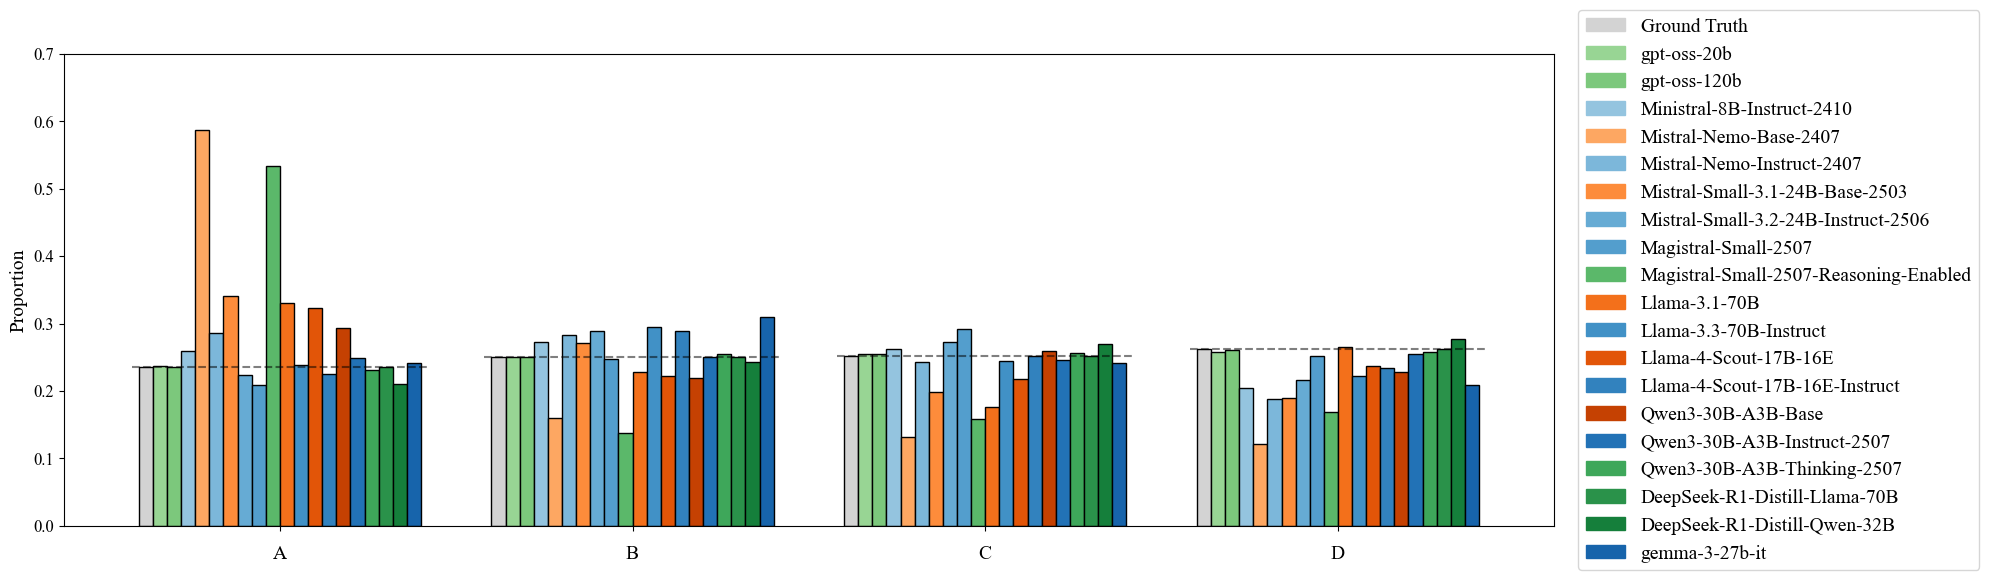

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Data Setup ----
labels = ["A", "B", "C", "D"]
num_labels = len(labels)

# Extract ground truth distribution
ground_truth = [actual_correct_label_proportion[i] for i in range(num_labels)]

# Extract model distributions
model_ids = list(labels_chosen_proportion.keys())
model_distributions = {
    model_id: [labels_chosen_proportion[model_id][i] for i in range(num_labels)]
    for model_id in model_ids
}

# Categorize models
categories = {
    "instruct": ("Blues", [m["id"] for m in models if m["type"] == "instruct"]),
    "base": ("Oranges", [m["id"] for m in models if m["type"] == "base"]),
    "reasoning": ("Greens", [m["id"] for m in models if m["type"] == "reasoning"]),
}

# Assign colors
model_colors = {}
for cmap, ids in [(plt.cm.get_cmap(c[0]), c[1]) for c in categories.values()]:
    colors = cmap(np.linspace(0.4, 0.8, len(ids)))
    model_colors.update({model: colors[i] for i, model in enumerate(ids)})

ground_truth_color = "lightgrey"

# ---- Plotting ----
fig, ax = plt.subplots(figsize=(20, 6))
bar_width = 0.04
x = np.arange(num_labels)

# Plot Ground Truth
ax.bar(
    x - bar_width * (len(models) / 2),
    ground_truth,
    bar_width,
    label="Ground Truth",
    color=ground_truth_color,
    edgecolor="black",
)

# Plot models
for i, model_id in enumerate(model_ids):
    ax.bar(
        x - bar_width * (len(model_ids) / 2) + (i + 1) * bar_width,
        model_distributions[model_id],
        bar_width,
        label=model_id,
        color=model_colors[model_id],
        edgecolor="black",
    )

# ---- Add ground truth reference lines ----
for i, gt in enumerate(ground_truth):
    ax.hlines(
        y=gt,
        xmin=x[i] - bar_width * (len(model_ids) / 2 + 1),
        xmax=x[i] + bar_width * (len(model_ids) / 2 + 1),
        colors="black",
        linestyles="dashed",
        alpha=0.5,
    )

# ---- Formatting ----
ax.set_xticks(x, labels, fontsize=14)
ax.set_yticks(np.arange(0.0, 0.7 + 0.1, 0.1))
ax.set_yticklabels([round(v, 1) for v in np.arange(0.0, 0.7 + 0.1, 0.1)], fontsize=12)
ax.tick_params(axis="x", pad=10)
ax.set_ylabel("Proportion", fontsize=14)
ax.set_ylim(0, 0.7)

# ---- Legend ----
handles = [plt.Rectangle((0, 0), 1, 1, color=ground_truth_color, edgecolor="black")]
handles += [
    plt.Rectangle((0, 0), 1, 1, color=model_colors[m], edgecolor="black")
    for m in model_ids
]
labels_legend = ["Ground Truth"] + model_ids
ax.legend(
    handles, labels_legend,
    loc="center left",          # anchor legend to the left-center of its box
    bbox_to_anchor=(1.01, 0.5), # place that box just outside the axes
    fontsize=14
)

plt.tight_layout()
plt.savefig("resources/figures/label_bias_estimations.svg", bbox_inches="tight")
plt.savefig("resources/figures/label_bias_estimations.png", bbox_inches="tight")
plt.show()